# Dataset Link: https://www.kaggle.com/datasets/kishoresabbavarapu/breast-cancer-image-dataset

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
import shutil

source_dir = r"C:\Users\Abdullah\__torch\Datasets\Ultrasound Breast Cancer Images"


image_dir = os.path.join(source_dir, "images")
mask_dir = os.path.join(source_dir, "masks")


os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)


for filename in os.listdir(source_dir):
    file_path = os.path.join(source_dir, filename)

    if os.path.isdir(file_path):
        continue

    if "_mask" in filename:
        shutil.move(file_path, os.path.join(mask_dir, filename))
    else:
        shutil.move(file_path, os.path.join(image_dir, filename))

print("Done organizing dataset")

Done organizing dataset


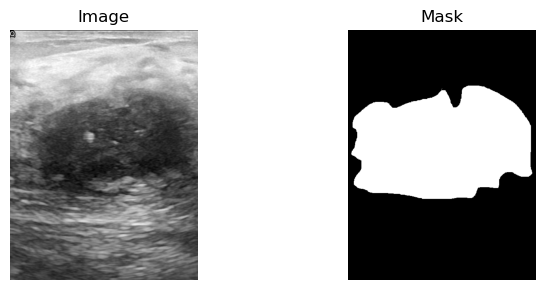

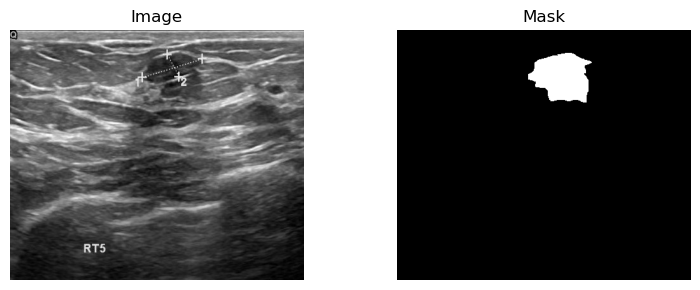

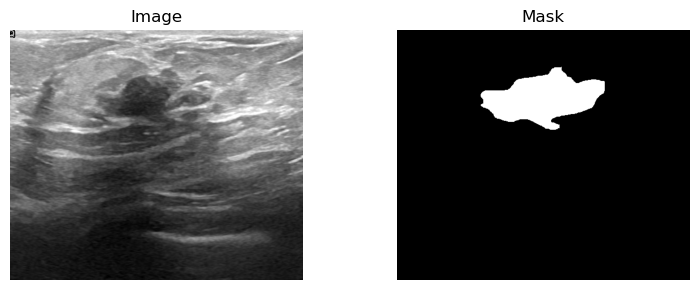

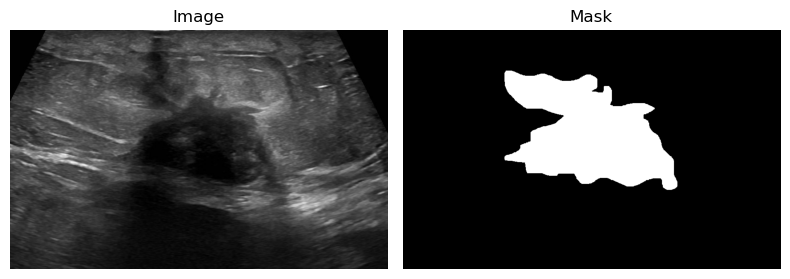

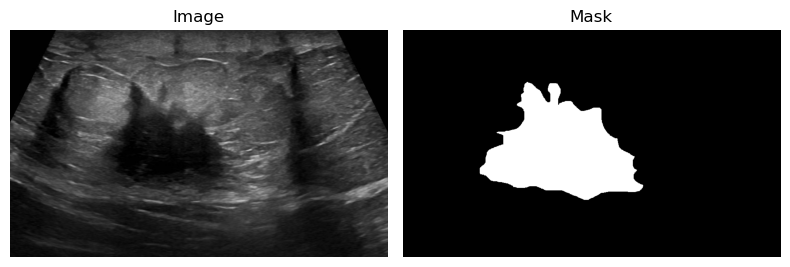

In [3]:
images = os.listdir(image_dir)

images.sort()

num_samples = 5

for i in range(num_samples):
    img_name = images[i]

    # corresponding mask name
    mask_name = img_name.replace(".png", "_mask.png")

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    # read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # read mask (grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # plot
    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
random_img_dir = os.listdir(image_dir)[1]
print(random_img_dir)

random_mask_dir = os.listdir(mask_dir)[1]

img = cv2.imread(os.path.join(image_dir, random_img_dir))
mask1 = cv2.imread(os.path.join(mask_dir, random_mask_dir))
print(f'Shape of the Image {img.shape} || Shape of the Mask {mask1.shape}')

malignant(10).png
Shape of the Image (393, 462, 3) || Shape of the Mask (393, 462, 3)


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    

    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.3),


    A.GaussNoise(p=0.2),

    A.Normalize(mean=(0.0, 0.0, 0.0),
                std=(1.0, 1.0, 1.0)),

    ToTensorV2()
])

C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.0, 0.0, 0.0),
                std=(1.0, 1.0, 1.0)),
    ToTensorV2()
])

In [7]:
class BreastDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".png", "_mask.png"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        image = image / 255.0
        mask = (mask > 0).astype("float32")

        # to tensor format
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, 0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bridge(self.pool3(d3))

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return torch.sigmoid(self.out(u1))

In [9]:
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = BreastDataset(
    image_dir,
    mask_dir,
    transform=train_transform
)

val_dataset = BreastDataset(
    image_dir,
    mask_dir,
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = UNet().to(device)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay= 1e-4)

In [12]:
save_dir = "unet_model"
os.makedirs(save_dir, exist_ok=True)

best_val_loss = float("inf")
thres = 5
counter = 0
epochs = 40

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader: 
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:  
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = dice_loss(preds, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| Train Loss: {train_loss:.4f} "
          f"| Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        print("Validation improved → saving model")

        best_val_loss = val_loss
        counter = 0

        model_path = os.path.join(save_dir, "best_model.pth")

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": best_val_loss
        }, model_path)

    else:
        counter += 1
        
    if counter >= thres:
        print("Early stopping triggered...")
        break

Epoch [1/40] | Train Loss: 0.7632 | Val Loss: 0.7679
Validation improved → saving model
Epoch [2/40] | Train Loss: 0.7621 | Val Loss: 0.7568
Validation improved → saving model
Epoch [3/40] | Train Loss: 0.7404 | Val Loss: 0.7267
Validation improved → saving model
Epoch [4/40] | Train Loss: 0.7091 | Val Loss: 0.7085
Validation improved → saving model
Epoch [5/40] | Train Loss: 0.7079 | Val Loss: 0.6916
Validation improved → saving model
Epoch [6/40] | Train Loss: 0.6911 | Val Loss: 0.6878
Validation improved → saving model
Epoch [7/40] | Train Loss: 0.6805 | Val Loss: 0.6856
Validation improved → saving model
Epoch [8/40] | Train Loss: 0.6828 | Val Loss: 0.6836
Validation improved → saving model
Epoch [9/40] | Train Loss: 0.6867 | Val Loss: 0.6822
Validation improved → saving model
Epoch [10/40] | Train Loss: 0.6819 | Val Loss: 0.6809
Validation improved → saving model
Epoch [11/40] | Train Loss: 0.6753 | Val Loss: 0.6704
Validation improved → saving model
Epoch [12/40] | Train Loss: 0.

In [13]:
model = UNet().to(device)

checkpoint = torch.load("unet_model/best_model.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded model from epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_19708\3032030141.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("unet_model/best_model.pth", map_

Loaded model from epoch: 36
Validation loss: 0.3829763276236398


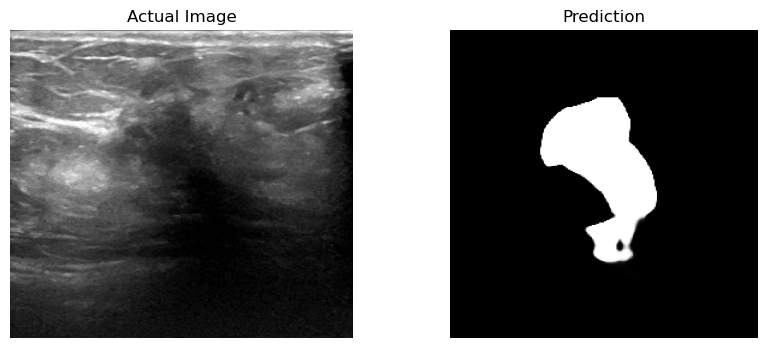

In [19]:
random_img_dir = os.listdir(image_dir)[200]

img = cv2.imread(os.path.join(image_dir, random_img_dir))
img_actual = img
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

img = img / 255.0
img = np.transpose(img, (2, 0, 1))
img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(img)

pred = pred.squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Actual Image")
plt.imshow(img_actual)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")
plt.axis("off")

plt.show()